### importing files and libraries

In [6]:
import os
import sys
import numpy as np
import pandas as pd

project_root = r"C:\Users\Arafat\Desktop\IMA Project"
if project_root not in sys.path:
    sys.path.append(project_root)

from src import config
from src import pipelines
from src import evaluation
from src import visualization
from src.knn import MyKNNClassifier, SklearnKNNWrapper
from src.utils import set_random_seed

from sklearn.preprocessing import StandardScaler

config.make_all_dirs()
set_random_seed(42)


[utils] Random seed set to 42


### load label mapping

In [7]:
label_map_path = os.path.join(config.PROCESSED_DATA_DIR, "label_mapping.csv")
label_map_df = pd.read_csv(label_map_path)
class_names = list(label_map_df["class_name"])
print("Class names:", class_names)


Class names: ['EOSINOPHIL', 'LYMPHOCYTE', 'MONOCYTE', 'NEUTROPHIL']


### function to load features for a pipeline

In [8]:
def load_pipeline_features(pipe_name: str):
    """
    here I want to load the .npz file for a given pipeline
    and also scale the features.
    """
    pipe_folder = os.path.join(config.FEATURES_DIR, pipe_name)
    npz_path = os.path.join(pipe_folder, f"{pipe_name}_features.npz")
    print("Loading features from:", npz_path)
    data = np.load(npz_path)

    feat_train = data["feat_train"]
    feat_val = data["feat_val"]
    feat_test = data["feat_test"]
    y_train = data["y_train"]
    y_val = data["y_val"]
    y_test = data["y_test"]

    print("Original train feature shape:", feat_train.shape)

    # I scale the features so they have zero mean and unit variance
    scaler = StandardScaler()
    feat_train_scaled = scaler.fit_transform(feat_train)
    feat_val_scaled = scaler.transform(feat_val)
    feat_test_scaled = scaler.transform(feat_test)

    print("Scaled train feature shape:", feat_train_scaled.shape)

    return feat_train_scaled, feat_val_scaled, feat_test_scaled, y_train, y_val, y_test


###  baseline pipelines and k list

In [9]:
# try all pipeline
baseline_pipelines = ["RawPixels", "GrayHist", "ColorHists", "Texture_LBP_GLCM", "EdgesAndTexture", "Frequency_FFT_DCT", "Morphology_GrayHist", "Combo_BestGuess"]
print("Baseline pipelines:", baseline_pipelines)

k_list = [3, 4, 5]
print("k values I will test:", k_list)


Baseline pipelines: ['RawPixels', 'GrayHist', 'ColorHists', 'Texture_LBP_GLCM', 'EdgesAndTexture', 'Frequency_FFT_DCT', 'Morphology_GrayHist', 'Combo_BestGuess']
k values I will test: [3, 4, 5]


# Cell 5 – MyKNN baselines

In [10]:
all_results = []

for pipe_name in baseline_pipelines:
    print("Pipeline:", pipe_name)

    feat_train, feat_val, feat_test, y_train, y_val, y_test = load_pipeline_features(pipe_name)

    # I will use MyKNNClassifier with L2 distance and no weighting
    # I will iterate over k values and see metrics on the validation set
    for k_value in k_list:
        print(f"\n[MyKNN] Pipeline: {pipe_name}, k = {k_value}")
        my_knn = MyKNNClassifier(k_value=k_value, distance_metric="l2", use_distance_weight=False)
        my_knn.fit(feat_train, y_train)
        y_val_pred = my_knn.predict(feat_val)

        metrics_dict = evaluation.compute_basic_metrics(y_val, y_val_pred)
        metrics_dict["pipeline"] = pipe_name
        metrics_dict["k_value"] = k_value
        metrics_dict["model_type"] = "MyKNN"
        all_results.append(metrics_dict)

        print("Validation metrics:", metrics_dict)



Pipeline: RawPixels
Loading features from: C:\Users\Arafat\Desktop\IMA Project\data\processed\features\RawPixels\RawPixels_features.npz
Original train feature shape: (7466, 16384)
Scaled train feature shape: (7466, 16384)

[MyKNN] Pipeline: RawPixels, k = 3
[MyKNN] Stored training data with shape: (7466, 16384)
[MyKNN] Predicted 50/2489 samples
[MyKNN] Predicted 100/2489 samples
[MyKNN] Predicted 150/2489 samples
[MyKNN] Predicted 200/2489 samples
[MyKNN] Predicted 250/2489 samples
[MyKNN] Predicted 300/2489 samples
[MyKNN] Predicted 350/2489 samples
[MyKNN] Predicted 400/2489 samples
[MyKNN] Predicted 450/2489 samples
[MyKNN] Predicted 500/2489 samples
[MyKNN] Predicted 550/2489 samples
[MyKNN] Predicted 600/2489 samples
[MyKNN] Predicted 650/2489 samples
[MyKNN] Predicted 700/2489 samples
[MyKNN] Predicted 750/2489 samples
[MyKNN] Predicted 800/2489 samples
[MyKNN] Predicted 850/2489 samples
[MyKNN] Predicted 900/2489 samples
[MyKNN] Predicted 950/2489 samples
[MyKNN] Predicted 1000

### converting results to DataFrame and visualize

In [11]:
df_results = pd.DataFrame(all_results)
print("All baseline results:")
df_results


All baseline results:


,accuracy,macro_precision,macro_recall,macro_f1,pipeline,k_value,model_type
0,0.498192,0.515854,0.498469,0.495947,RawPixels,3,MyKNN
1,0.490157,0.509294,0.490413,0.487860,RawPixels,4,MyKNN
2,0.493773,0.507788,0.494062,0.488444,RawPixels,5,MyKNN
3,0.894737,0.899283,0.895020,0.893401,GrayHist,3,MyKNN
4,0.874247,0.882150,0.874601,0.871194,GrayHist,4,MyKNN
5,0.888710,0.891828,0.889027,0.886609,GrayHist,5,MyKNN
6,0.960627,0.961172,0.960731,0.960625,ColorHists,3,MyKNN
7,0.958618,0.959872,0.958748,0.958494,ColorHists,4,MyKNN
8,0.959823,0.960184,0.959958,0.959609,ColorHists,5,MyKNN
9,0.766171,0.768577,0.766687,0.759488,Texture_LBP_GLCM,3,MyKNN


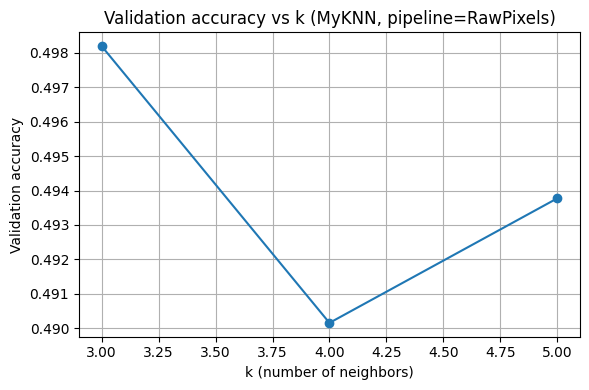

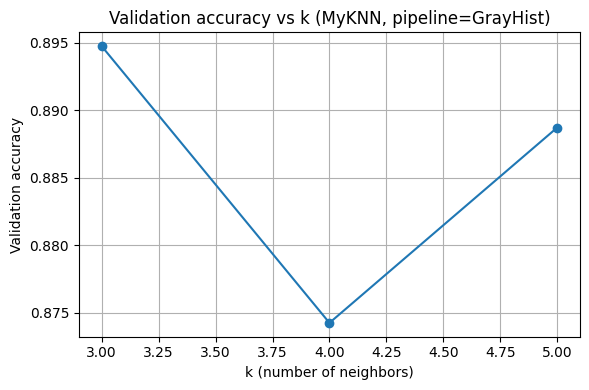

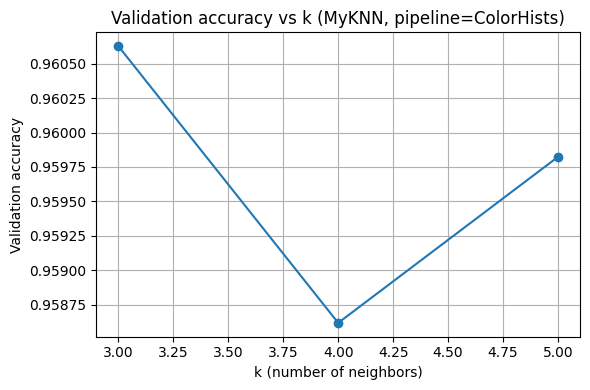

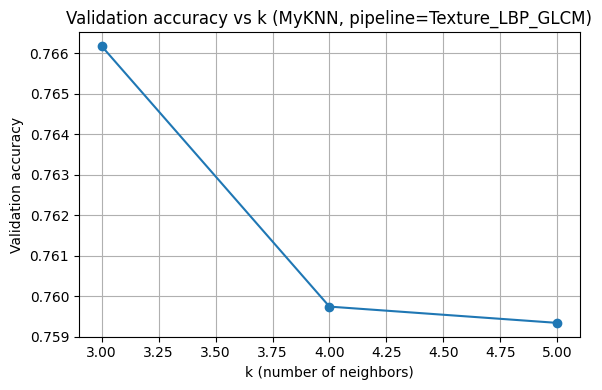

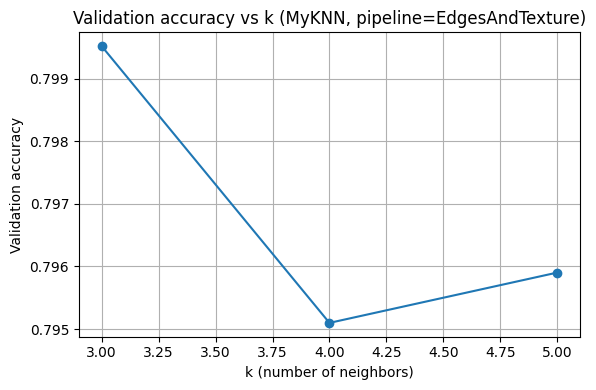

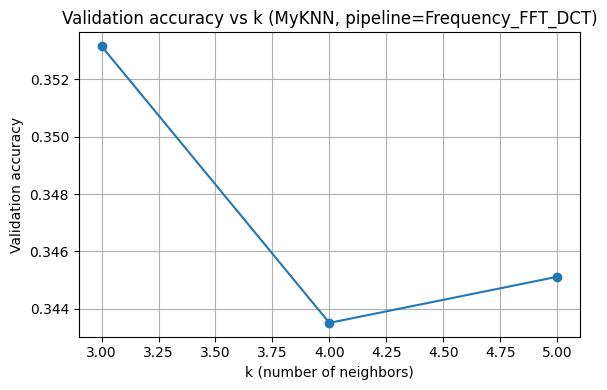

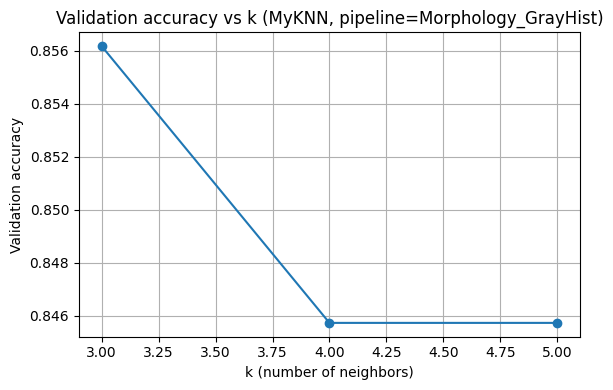

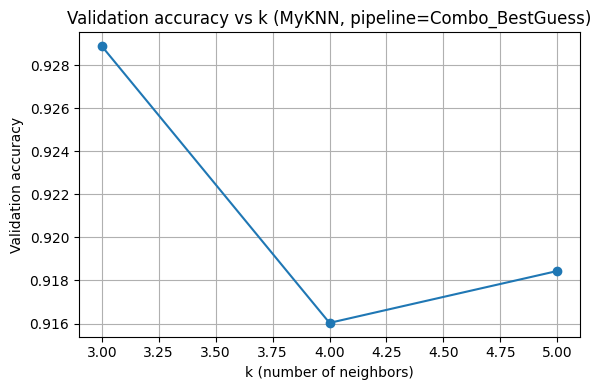

In [12]:
# Here I plot accuracy vs k for each pipeline
for pipe_name in baseline_pipelines:
    temp_df = df_results[(df_results["pipeline"] == pipe_name) & (df_results["model_type"] == "MyKNN")]
    visualization.plot_accuracy_vs_k(
        temp_df,
        title=f"Validation accuracy vs k (MyKNN, pipeline={pipe_name})",
    )


### choosing best k per pipeline and evaluate on test set

In [15]:
best_rows = []

for pipe_name in baseline_pipelines:
    temp_df = df_results[df_results["pipeline"] == pipe_name]

    # if for some reason this pipeline has no rows, I don't want the code to crash
    if temp_df.empty:
        print(f"no rows found for pipeline = {pipe_name}. need to check the pipeline name.")
        continue

    # idxmax gives me the original index label, so I must use .loc (NOT .iloc)
    best_idx = temp_df["macro_f1"].idxmax()
    best_row = temp_df.loc[best_idx]

    best_rows.append(best_row)

best_df = pd.DataFrame(best_rows).reset_index(drop=True)
print("Best config per pipeline (based on val macro F1):")
best_df


Best config per pipeline (based on val macro F1):


,accuracy,macro_precision,macro_recall,macro_f1,pipeline,k_value,model_type
0,0.498192,0.515854,0.498469,0.495947,RawPixels,3,MyKNN
1,0.894737,0.899283,0.895020,0.893401,GrayHist,3,MyKNN
2,0.960627,0.961172,0.960731,0.960625,ColorHists,3,MyKNN
3,0.766171,0.768577,0.766687,0.759488,Texture_LBP_GLCM,3,MyKNN
4,0.799518,0.800708,0.799984,0.795155,EdgesAndTexture,3,MyKNN
5,0.353154,0.373577,0.353135,0.352148,Frequency_FFT_DCT,3,MyKNN
6,0.856167,0.863453,0.856518,0.854216,Morphology_GrayHist,3,MyKNN
7,0.928887,0.930937,0.929091,0.928289,Combo_BestGuess,3,MyKNN



Evaluating pipeline RawPixels on TEST with k=3
Loading features from: C:\Users\Arafat\Desktop\IMA Project\data\processed\features\RawPixels\RawPixels_features.npz
Original train feature shape: (7466, 16384)
Scaled train feature shape: (7466, 16384)
[MyKNN] Stored training data with shape: (9955, 16384)
[MyKNN] Predicted 50/2489 samples
[MyKNN] Predicted 100/2489 samples
[MyKNN] Predicted 150/2489 samples
[MyKNN] Predicted 200/2489 samples
[MyKNN] Predicted 250/2489 samples
[MyKNN] Predicted 300/2489 samples
[MyKNN] Predicted 350/2489 samples
[MyKNN] Predicted 400/2489 samples
[MyKNN] Predicted 450/2489 samples
[MyKNN] Predicted 500/2489 samples
[MyKNN] Predicted 550/2489 samples
[MyKNN] Predicted 600/2489 samples
[MyKNN] Predicted 650/2489 samples
[MyKNN] Predicted 700/2489 samples
[MyKNN] Predicted 750/2489 samples
[MyKNN] Predicted 800/2489 samples
[MyKNN] Predicted 850/2489 samples
[MyKNN] Predicted 900/2489 samples
[MyKNN] Predicted 950/2489 samples
[MyKNN] Predicted 1000/2489 sam

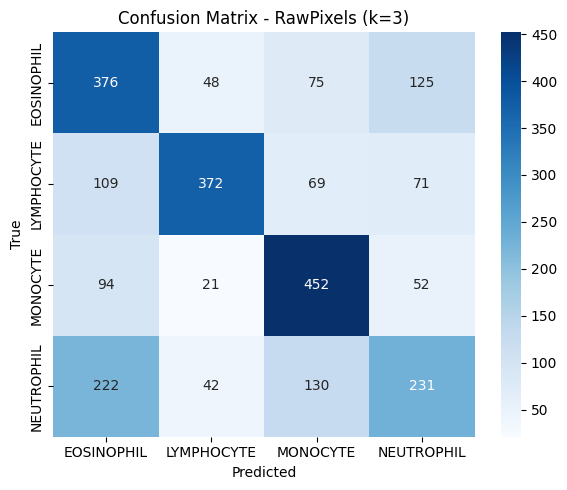

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.47      0.60      0.53       624
           1       0.77      0.60      0.67       621
           2       0.62      0.73      0.67       619
           3       0.48      0.37      0.42       625

    accuracy                           0.57      2489
   macro avg       0.59      0.58      0.57      2489
weighted avg       0.59      0.57      0.57      2489


Evaluating pipeline GrayHist on TEST with k=3
Loading features from: C:\Users\Arafat\Desktop\IMA Project\data\processed\features\GrayHist\GrayHist_features.npz
Original train feature shape: (7466, 32)
Scaled train feature shape: (7466, 32)
[MyKNN] Stored training data with shape: (9955, 32)
[MyKNN] Predicted 50/2489 samples
[MyKNN] Predicted 100/2489 samples
[MyKNN] Predicted 150/2489 samples
[MyKNN] Predicted 200/2489 samples
[MyKNN] Predicted 250/2489 samples
[MyKNN] Predicted 300/2489 samples
[MyKNN] Predicted 350/2489 sample

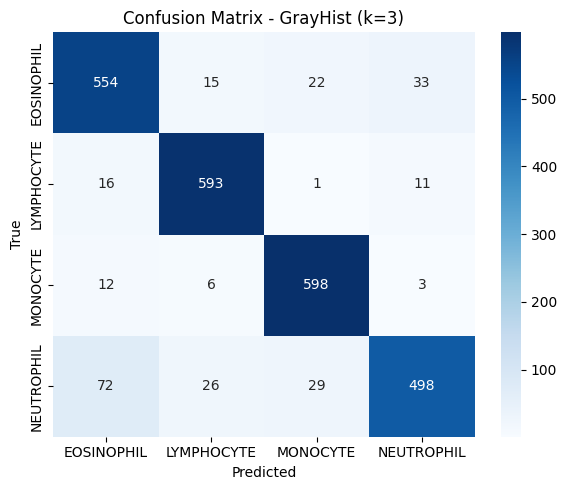

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.85      0.89      0.87       624
           1       0.93      0.95      0.94       621
           2       0.92      0.97      0.94       619
           3       0.91      0.80      0.85       625

    accuracy                           0.90      2489
   macro avg       0.90      0.90      0.90      2489
weighted avg       0.90      0.90      0.90      2489


Evaluating pipeline ColorHists on TEST with k=3
Loading features from: C:\Users\Arafat\Desktop\IMA Project\data\processed\features\ColorHists\ColorHists_features.npz
Original train feature shape: (7466, 96)
Scaled train feature shape: (7466, 96)
[MyKNN] Stored training data with shape: (9955, 96)
[MyKNN] Predicted 50/2489 samples
[MyKNN] Predicted 100/2489 samples
[MyKNN] Predicted 150/2489 samples
[MyKNN] Predicted 200/2489 samples
[MyKNN] Predicted 250/2489 samples
[MyKNN] Predicted 300/2489 samples
[MyKNN] Predicted 350/2489 

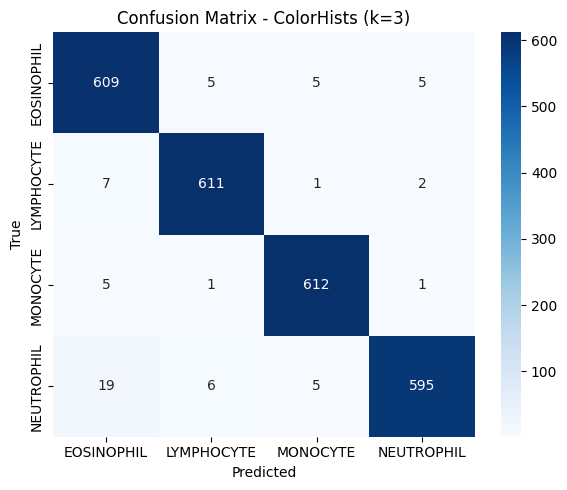

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.95      0.98      0.96       624
           1       0.98      0.98      0.98       621
           2       0.98      0.99      0.99       619
           3       0.99      0.95      0.97       625

    accuracy                           0.98      2489
   macro avg       0.98      0.98      0.98      2489
weighted avg       0.98      0.98      0.98      2489


Evaluating pipeline Texture_LBP_GLCM on TEST with k=3
Loading features from: C:\Users\Arafat\Desktop\IMA Project\data\processed\features\Texture_LBP_GLCM\Texture_LBP_GLCM_features.npz
Original train feature shape: (7466, 67)
Scaled train feature shape: (7466, 67)
[MyKNN] Stored training data with shape: (9955, 67)
[MyKNN] Predicted 50/2489 samples
[MyKNN] Predicted 100/2489 samples
[MyKNN] Predicted 150/2489 samples
[MyKNN] Predicted 200/2489 samples
[MyKNN] Predicted 250/2489 samples
[MyKNN] Predicted 300/2489 samples
[MyKNN] P

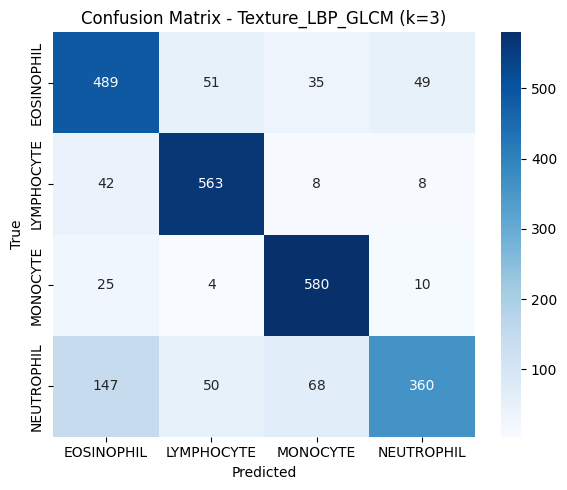

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.70      0.78      0.74       624
           1       0.84      0.91      0.87       621
           2       0.84      0.94      0.89       619
           3       0.84      0.58      0.68       625

    accuracy                           0.80      2489
   macro avg       0.81      0.80      0.80      2489
weighted avg       0.81      0.80      0.79      2489


Evaluating pipeline EdgesAndTexture on TEST with k=3
Loading features from: C:\Users\Arafat\Desktop\IMA Project\data\processed\features\EdgesAndTexture\EdgesAndTexture_features.npz
Original train feature shape: (7466, 51)
Scaled train feature shape: (7466, 51)
[MyKNN] Stored training data with shape: (9955, 51)
[MyKNN] Predicted 50/2489 samples
[MyKNN] Predicted 100/2489 samples
[MyKNN] Predicted 150/2489 samples
[MyKNN] Predicted 200/2489 samples
[MyKNN] Predicted 250/2489 samples
[MyKNN] Predicted 300/2489 samples
[MyKNN] Pred

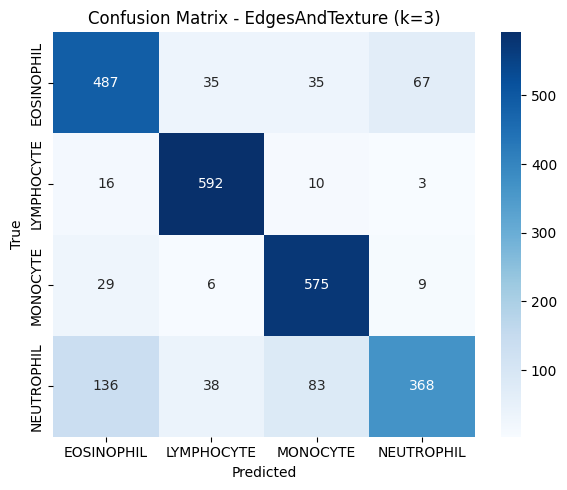

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.73      0.78      0.75       624
           1       0.88      0.95      0.92       621
           2       0.82      0.93      0.87       619
           3       0.82      0.59      0.69       625

    accuracy                           0.81      2489
   macro avg       0.81      0.81      0.81      2489
weighted avg       0.81      0.81      0.81      2489


Evaluating pipeline Frequency_FFT_DCT on TEST with k=3
Loading features from: C:\Users\Arafat\Desktop\IMA Project\data\processed\features\Frequency_FFT_DCT\Frequency_FFT_DCT_features.npz
Original train feature shape: (7466, 72)
Scaled train feature shape: (7466, 72)
[MyKNN] Stored training data with shape: (9955, 72)
[MyKNN] Predicted 50/2489 samples
[MyKNN] Predicted 100/2489 samples
[MyKNN] Predicted 150/2489 samples
[MyKNN] Predicted 200/2489 samples
[MyKNN] Predicted 250/2489 samples
[MyKNN] Predicted 300/2489 samples
[MyKNN

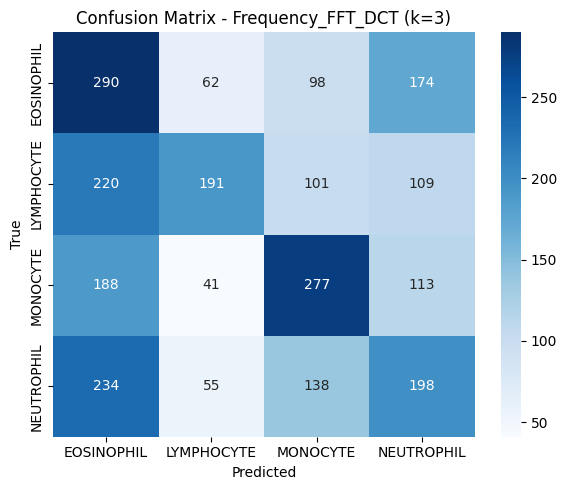

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.31      0.46      0.37       624
           1       0.55      0.31      0.39       621
           2       0.45      0.45      0.45       619
           3       0.33      0.32      0.32       625

    accuracy                           0.38      2489
   macro avg       0.41      0.38      0.39      2489
weighted avg       0.41      0.38      0.39      2489


Evaluating pipeline Morphology_GrayHist on TEST with k=3
Loading features from: C:\Users\Arafat\Desktop\IMA Project\data\processed\features\Morphology_GrayHist\Morphology_GrayHist_features.npz
Original train feature shape: (7466, 38)
Scaled train feature shape: (7466, 38)
[MyKNN] Stored training data with shape: (9955, 38)
[MyKNN] Predicted 50/2489 samples
[MyKNN] Predicted 100/2489 samples
[MyKNN] Predicted 150/2489 samples
[MyKNN] Predicted 200/2489 samples
[MyKNN] Predicted 250/2489 samples
[MyKNN] Predicted 300/2489 samples


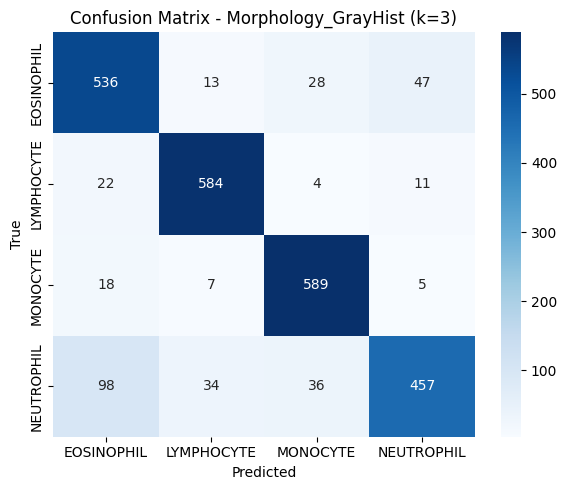

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.80      0.86      0.83       624
           1       0.92      0.94      0.93       621
           2       0.90      0.95      0.92       619
           3       0.88      0.73      0.80       625

    accuracy                           0.87      2489
   macro avg       0.87      0.87      0.87      2489
weighted avg       0.87      0.87      0.87      2489


Evaluating pipeline Combo_BestGuess on TEST with k=3
Loading features from: C:\Users\Arafat\Desktop\IMA Project\data\processed\features\Combo_BestGuess\Combo_BestGuess_features.npz
Original train feature shape: (7466, 91)
Scaled train feature shape: (7466, 91)
[MyKNN] Stored training data with shape: (9955, 91)
[MyKNN] Predicted 50/2489 samples
[MyKNN] Predicted 100/2489 samples
[MyKNN] Predicted 150/2489 samples
[MyKNN] Predicted 200/2489 samples
[MyKNN] Predicted 250/2489 samples
[MyKNN] Predicted 300/2489 samples
[MyKNN] Pred

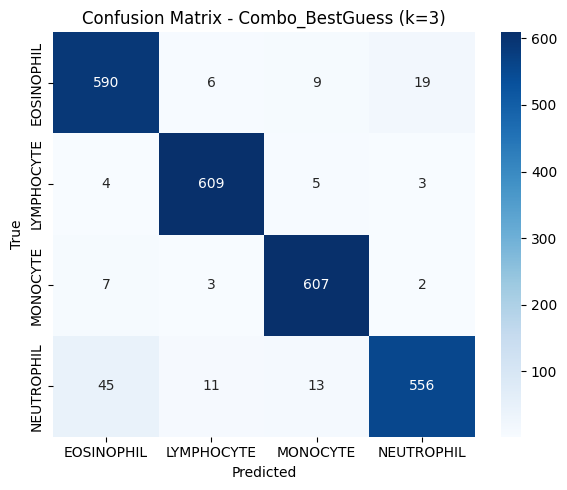

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.91      0.95      0.93       624
           1       0.97      0.98      0.97       621
           2       0.96      0.98      0.97       619
           3       0.96      0.89      0.92       625

    accuracy                           0.95      2489
   macro avg       0.95      0.95      0.95      2489
weighted avg       0.95      0.95      0.95      2489



In [16]:
# Now I actually evaluate those best configs on the test set
for idx, row in best_df.iterrows():
    pipe_name = row["pipeline"]
    best_k = int(row["k_value"])
    print("\n==============================")
    print(f"Evaluating pipeline {pipe_name} on TEST with k={best_k}")

    feat_train, feat_val, feat_test, y_train, y_val, y_test = load_pipeline_features(pipe_name)

    my_knn = MyKNNClassifier(k_value=best_k, distance_metric="l2", use_distance_weight=False)
    my_knn.fit(np.vstack([feat_train, feat_val]), np.concatenate([y_train, y_val]))
    y_test_pred = my_knn.predict(feat_test)

    metrics_test = evaluation.compute_basic_metrics(y_test, y_test_pred)
    print("Test metrics:", metrics_test)

    cm = evaluation.compute_confusion(y_test, y_test_pred, label_order=list(range(len(class_names))))
    visualization.plot_confusion_matrix(cm, class_names=class_names, title=f"Confusion Matrix - {pipe_name} (k={best_k})")

    evaluation.print_detailed_classification_report(y_test, y_test_pred)
